In [18]:
import pandas as pd
import networkx as nx
import community as community_louvain
from networkx.algorithms.community import greedy_modularity_communities, girvan_newman, modularity

# Spotify songs extraction from 'Top songs of 2000-2023' playlist

In [38]:
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials
import pandas as pd
import json

# Load credentials from a JSON file
credentials = json.load(open('credentials.json'))
client_id = credentials['client_id']
client_secret = credentials['client_secret']

# Initialize Spotify client
client_credentials_manager = SpotifyClientCredentials(client_id=client_id, client_secret=client_secret)
sp = spotipy.Spotify(client_credentials_manager=client_credentials_manager)

# Function to extract MetaData from a playlist that's longer than 100 songs
def get_playlist_tracks_more_than_100_songs(username, playlist_id):
    results = sp.user_playlist_tracks(username, playlist_id)
    tracks = results['items']
    while results['next']:
        results = sp.next(results)
        tracks.extend(results['items'])

    print(f"Total tracks fetched: {len(tracks)}")

    # Initialize lists to store track details
    playlist_tracks_id = []
    playlist_tracks_titles = []
    playlist_tracks_artists = []
    playlist_tracks_first_release_date = []
    playlist_tracks_popularity = []

    # Extract track details
    for i, track in enumerate(tracks):
        print(f"Processing track {i + 1}/{len(tracks)}")
        playlist_tracks_id.append(track['track']['id'])
        playlist_tracks_titles.append(track['track']['name'])
        playlist_tracks_first_release_date.append(track['track']['album']['release_date'])
        playlist_tracks_popularity.append(track['track']['popularity'])

        artist_list = [artist['name'] for artist in track['track']['artists']]
        playlist_tracks_artists.append(artist_list)

    # Fetch audio features in batches
    def fetch_audio_features_in_batches(track_ids, batch_size=100):
        features = []
        for i in range(0, len(track_ids), batch_size):
            batch = track_ids[i:i + batch_size]
            features.extend(sp.audio_features(batch))
        return features

    print("Fetching audio features...")
    audio_features = fetch_audio_features_in_batches(playlist_tracks_id)

    # Convert features to DataFrame
    print("Converting features to DataFrame...")
    features_df = pd.DataFrame(data=audio_features, columns=audio_features[0].keys())
    features_df['title'] = playlist_tracks_titles
    features_df['all_artists'] = playlist_tracks_artists
    features_df['popularity'] = playlist_tracks_popularity
    features_df['release_date'] = playlist_tracks_first_release_date

    # Select relevant columns
    features_df = features_df[['id', 'title', 'all_artists', 'popularity', 'release_date',
                               'danceability', 'energy', 'key', 'loudness', 'mode', 'acousticness',
                               'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'time_signature']]

    return features_df


# Provided playlist URL
playlist_url = 'https://open.spotify.com/playlist/6Q1m6h43xSG5yiT4gzDHoW?si=4dd439e990974000'

# Extract playlist ID from URL
playlist_id = playlist_url.split('/')[-1].split('?')[0]

# Username (can be left empty if not necessary)
username = ''

# Get the playlist data
df_spotify = get_playlist_tracks_more_than_100_songs(username, playlist_id)

# Save the DataFrame to a CSV file
df_spotify.to_csv(r"C:\\Users\\avita\\Downloads\\playlist_features_2000-2023.csv", index=False, encoding='utf-8')

print("Data saved to playlist_features_2000-2023.csv")

Total tracks fetched: 893
Processing track 1/893
Processing track 2/893
Processing track 3/893
Processing track 4/893
Processing track 5/893
Processing track 6/893
Processing track 7/893
Processing track 8/893
Processing track 9/893
Processing track 10/893
Processing track 11/893
Processing track 12/893
Processing track 13/893
Processing track 14/893
Processing track 15/893
Processing track 16/893
Processing track 17/893
Processing track 18/893
Processing track 19/893
Processing track 20/893
Processing track 21/893
Processing track 22/893
Processing track 23/893
Processing track 24/893
Processing track 25/893
Processing track 26/893
Processing track 27/893
Processing track 28/893
Processing track 29/893
Processing track 30/893
Processing track 31/893
Processing track 32/893
Processing track 33/893
Processing track 34/893
Processing track 35/893
Processing track 36/893
Processing track 37/893
Processing track 38/893
Processing track 39/893
Processing track 40/893
Processing track 41/893

Converting features to DataFrame...
Data saved to playlist_features_2000-2023.csv


In [39]:
df_spotify

,id,title,all_artists,popularity,release_date,danceability,energy,key,loudness,mode,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
0,5l3CML2OnzfNs5RfVgbcLt,Talk Dirty (feat. 2 Chainz),"[Jason Derulo, 2 Chainz]",70,2013-09-10,0.760,0.652,6,-7.321,1,0.034800,0.000000,0.3070,0.759,100.315,177685,4
1,7KXjTSCq5nL1LoYtL7XAwS,HUMBLE.,[Kendrick Lamar],85,2017-04-14,0.908,0.621,1,-6.638,0,0.000282,0.000054,0.0958,0.421,150.011,177000,4
2,4rHZZAmHpZrA3iH5zx8frV,Mirrors,[Justin Timberlake],79,2013-03-15,0.574,0.512,5,-6.664,0,0.234000,0.000000,0.0946,0.512,76.899,484147,4
3,1zB4vmk8tFRmM9UULNzbLB,Thunder,[Imagine Dragons],85,2017-06-23,0.604,0.822,0,-4.833,1,0.006720,0.134000,0.1470,0.288,167.997,187147,4
4,0pqnGHJpmpxLKifKRmU6WP,Believer,[Imagine Dragons],86,2017-06-23,0.776,0.780,10,-4.374,0,0.062200,0.000000,0.0810,0.666,124.949,204347,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
888,5o4XJKRxUK6nXhFLAIS33A,Gimme Love,[Sia],70,2023-09-13,0.327,0.820,11,-2.591,1,0.003700,0.000876,0.6140,0.311,96.479,177922,4
889,7l9IqDtVWJurTvkQHq1BGh,she's all i wanna be,[Tate McRae],74,2022-05-27,0.602,0.626,2,-5.323,0,0.012900,0.000009,0.1440,0.619,160.118,207120,4
890,3xXBsjrbG1xQIm1xv1cKOt,One More Light,[Linkin Park],72,2017-05-19,0.593,0.200,8,-11.063,1,0.904000,0.000000,0.0897,0.170,83.966,255067,4
891,1a8JpAL3vbAdXYrEABvOtb,Amerika,[Rammstein],69,2004-09-27,0.608,0.885,2,-4.296,0,0.002580,0.000013,0.3920,0.518,125.023,226760,4


# Artist Features - Gaining More Artist Properties

To gain a deeper understanding of the artists involved in the playlist songs, we aim to add additional characteristics for each artist. Specifically, we will include the features: genre, number of followers, and popularity.

In [40]:
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials
import pandas as pd
import json
import time

df_spotify = pd.read_csv(r"playlist_features_2000-2023.csv", encoding='utf-8')
df_spotify.isnull().sum()

# Extract unique artists
unique_artists = []
for index, row in df_spotify.iterrows():
    artists = eval(row['all_artists'])
    for artist in artists:
        unique_artists.append(artist)

unique_artists = list(set(unique_artists))
# Number of different artists
len(unique_artists)

# Load credentials from a JSON file
credentials = json.load(open('credentials.json'))
client_id = credentials['client_id']
client_secret = credentials['client_secret']

# Initialize Spotify client
client_credentials_manager = SpotifyClientCredentials(client_id=client_id, client_secret=client_secret)
sp = spotipy.Spotify(client_credentials_manager=client_credentials_manager)

# Initialize lists to store artist features
artist_ids = []
artist_names = unique_artists
artist_followers = []
artist_popularity = []
artist_genres = []

# Fetch artist features
for i, artist_name in enumerate(artist_names):
    try:
        print(f"Processing artist {i + 1}/{len(artist_names)}: {artist_name}")
        results = sp.search(q=f'artist:{artist_name}', type='artist')
        if results['artists']['items']:
            artist = results['artists']['items'][0]
            artist_ids.append(artist['id'])
            artist_followers.append(artist['followers']['total'])
            artist_popularity.append(artist['popularity'])
            artist_genres.append(artist['genres'] if artist['genres'] else ['No genres available'])
        else:
            print(f"No results found for artist: {artist_name}")
            artist_ids.append('N/A')
            artist_followers.append(0)
            artist_popularity.append(0)
            artist_genres.append(['No genres available'])
    except spotipy.exceptions.SpotifyException as e:
        print(f"Spotify API error: {e}")
        if e.http_status == 429:  # Rate limit exceeded
            retry_after = int(e.headers.get('Retry-After', 10))
            print(f"Rate limit exceeded. Retrying after {retry_after} seconds...")
            time.sleep(retry_after)
            continue
    except Exception as e:
        print(f"Error processing artist {artist_name}: {e}")
        artist_ids.append('N/A')
        artist_followers.append(0)
        artist_popularity.append(0)
        artist_genres.append(['No genres available'])

# Create a DataFrame for artist features
artist_features_df = pd.DataFrame({
    'artist_id': artist_ids,
    'artist': artist_names,
    'followers': artist_followers,
    'popularity': artist_popularity,
    'genres': artist_genres
})

# Save the artist features DataFrame to a CSV file
artist_features_df.to_csv('artist_features.csv', index=False, encoding='utf-8')

Processing artist 1/667: Kiiara
Processing artist 2/667: A Great Big World
Processing artist 3/667: P!nk
Processing artist 4/667: Liefde Voor Muziek voor Rode Neuzen Dag
Processing artist 5/667: Harry Styles
Processing artist 6/667: Francesco Yates
Processing artist 7/667: Swae Lee
Processing artist 8/667: Within Temptation
Processing artist 9/667: Muse
Processing artist 10/667: The Chainsmokers
Processing artist 11/667: Charlie Puth
Processing artist 12/667: Creed
Processing artist 13/667: Duran Duran
Processing artist 14/667: Arizona Zervas
Processing artist 15/667: The Smashing Pumpkins
Processing artist 16/667: NF
Processing artist 17/667: Bizzey
Processing artist 18/667: Ludacris
Processing artist 19/667: Florence Welch
Processing artist 20/667: Fall Out Boy
Processing artist 21/667: Ruth B.
Processing artist 22/667: Grey
Processing artist 23/667: Chef'Special
No results found for artist: Chef'Special
Processing artist 24/667: Surf Mesa
Processing artist 25/667: J.J. Cale
Processi

KeyboardInterrupt: 

## Artists dataset pre-processing

### Exceptions - artists without characteristics

In [43]:
# Look at outliers
artist_features_df = pd.read_csv(r"C:\\Users\\avita\\Downloads\\artist_features_unclean.csv", encoding='utf-8')
errored_artists = artist_features_df[(artist_features_df['followers'] == 0) | (artist_features_df['popularity'] == 0)]
errored_artists

,artist_id,artist,followers,popularity,genres


### Genre exceptions and clean

A connection to the API returns for each artist a list of genres according to belonging to playlists in the various categories.
Actions we performed:

(1) Selection in a leading (first) category

(2) Division into central categories of genres - we chose the main categories

(3) Associating the variety of different genres to these categories - lowercase and finding the closest category using a function.

In [ ]:
artist_features_df = pd.read_csv(r"C:\\Users\\avita\\Downloads\\artist_features_unclean.csv", encoding='utf-8')
# Extract unique artists
unique_generes = []
for index, row in artist_features_df.iterrows():
    genres = eval(row['genres'])
    for genere in genres:
        unique_generes.append(genere)
unique_generes = list(set(unique_generes))
# Number of different artists
len(unique_generes)

# Update the 'genres' column to keep only the first genre
artist_features_df['genres'] = artist_features_df['genres'].apply(
    lambda x: eval(x)[0] if isinstance(eval(x), list) and eval(x) else 'No genres available')
unique_generes = artist_features_df['genres'].unique()
len(unique_generes)

# Define core genres
core_genres = ['pop', 'rock', 'hip hop', 'rap', 'r&b', 'country', 'latin', 'electronic', 'jazz', 'classical', 'metal',
               'indie', 'folk', 'reggae', 'dance', 'soul', 'funk']

# Function to map genre to core genre
def map_to_core_genre(genre):
    genre = genre.lower()  # Convert genre to lowercase for comparison
    for core_genre in core_genres:
        if core_genre in genre:
            return core_genre
    return genre


# Apply the mapping function to the 'genres' column
artist_features_df['genre'] = artist_features_df['genres'].apply(map_to_core_genre)
unique_generes = artist_features_df['genre'].unique()
len(unique_generes)

# Specific generes
specific_generes = [genre for genre in unique_generes if genre not in core_genres]

core_genres_specific = {
    'pop': ['scottish singer-songwriter', 'chill guitar', 'neo mellow', 'girl group', 'british soul', 'alt z',
            'new french touch', 'boy band', 'gen z singer-songwriter', 'kleinkunst', 'nouvelle chanson francaise',
            'irish singer-songwriter', 'lustrum', 'show tunes', 'soul', 'irish pop', 'folk-pop', 'indie pop',
            'neo soul'],
    'rock': ['canadian punk', 'birmingham grime', 'old school hard trance', 'grunge', 'british invasion', 'beatlesque',
             'acoustic punk', 'emo'],
    'electronic': ['elctro house', 'white noise', 'electro house', 'drum and bass', 'edm', 'house', 'lo-fi chill',
                   'aussietronica', 'uk funky', 'nordic house', 'dutch house', 'calming instrumental', 'ambeat',
                   'tech house', 'hypertechno', 'deep groove house', 'sped up', 'slap house', 'electro', 'complextro',
                   'breaks', 'deep euro house', 'deep house', 'disco house', 'downtempo', 'dutch trance', 'hip house',
                   'brostep', 'basshall', 'covertronica', 'beats', 'escape room', 'gaming edm', 'dark clubbing',
                   'funktronica', 'instrum', 'melbourne bounce international', 'classic hardstyle'],
    'hip hop': ['g funk', 'afrobeats', 'melodic drill', 'brooklyn drill', 'birmingham grime', 'uk funky',
                'drill francais'],
    'r&b': ['gospel', 'neo soul', 'southern soul', 'bedroom soul', 'afro soul', 'british soul'],
    'latin': ['kompa', 'gruperas inmortales', 'axe', 'corrido', 'banda', 'carnaval'],
    'metal': ['american melodeath'],
    'funk': ['funk', 'blues'],
    'folk': ['shanty'],
    'jazz': ['jawaiian'],
}

# Create a reverse mapping from specific genre to core genre
specific_to_core_mapping = {}
for core, specifics in core_genres_specific.items():
    for specific in specifics:
        specific_to_core_mapping[specific] = core


# Function to map specific genre to core genre
def map_to_specific_genre(genre):
    return specific_to_core_mapping.get(genre, 'pop')


# Apply manually mapping
artist_features_df['genre'] = artist_features_df['genre'].apply(
    lambda x: map_to_specific_genre(x) if x in specific_generes else x)

# Check if all the mapping worked - yes!
len([genre for genre in artist_features_df['genre'].unique() if genre not in core_genres])

# Drop the genres column
artist_features_df = artist_features_df.drop('genres', axis=1)

# Save the new artist's features df
artist_features_df.to_csv('C:\\Users\\avita\\Downloads\\artist_features_clean.csv', index=False, encoding='utf-8')

# SNA - Network representation

In [ ]:
import pandas as pd
from collections import defaultdict

# ~ Edge list

df_spotify = pd.read_csv(r"playlist_features_2000-2023.csv", encoding='ISO-8859-1')

# Initialize a dictionary to store collaboration counts
collaborations = defaultdict(int)

# Iteration on each song and add the collaboration between each pair
for index, row in df_spotify.iterrows():
    artists = eval(row['all_artists'])  # Convert the string representation of the list back to a list
    if len(artists) > 1:  # There is more than one artist preforming in the song
        for i in range(len(artists)):
            for j in range(i + 1, len(artists)):
                artist_pair = tuple(sorted([artists[i], artists[j]]))
                collaborations[artist_pair] += 1

# Create a DataFrame for the edge list
edges = pd.DataFrame([(a, b, count) for (a, b), count in collaborations.items()],
                     columns=['Source', 'Target', 'Weight'])

edges.to_csv('edges.csv', index=False, encoding='utf-8')

In [ ]:
# ~ Nodes list

df_artist_features = pd.read_csv(r"C:\\Users\\avita\\Downloads\\artist_features_clean.csv", encoding='utf-8')

# Rename columns to fit Gephi's expected format
df_artist_features = df_artist_features.rename(columns={
    'artist': 'Label',
    'artist_id': 'ID',
    'followers': 'Followers',
    'popularity': 'Popularity',
    'clean_genre': 'Genre'
})
df_artist_features.to_csv('nodes.csv', index=False, encoding='utf-8')

## Graph creation

In [19]:
# Load data
edges = pd.read_csv('Giant_edges.csv')
nodes = pd.read_csv('Giant_nodes.csv')

# Create graph
G = nx.Graph()

# Add nodes with attributes
for _, row in nodes.iterrows():
    G.add_node(row['ID'], followers=row['Followers'], genre=row['Genre'])

# Add edges with weights
for _, row in edges.iterrows():
    G.add_edge(row['Source'], row['Target'], weight=row['Weight'])

In [44]:
# Centrality measurements

import pandas as pd

nodes_df = pd.read_csv('Giant_nodes.csv')

# Identify the top centralized artists
degree_top = nodes_df.sort_values(by='Degree', ascending=False).head(10)
closeness_top = nodes_df.sort_values(by='Closeness', ascending=False).head(10)
harmonic_closeness_top = nodes_df.sort_values(by='Harmonic Closeness', ascending=False).head(10)
betweenness_top = nodes_df.sort_values(by='Between', ascending=False).head(10)

# Display the top artists for each centrality measure
print("Top artists by Degree:")
print(degree_top[['ID', 'Followers', 'Genre', 'Degree', 'Closeness', 'Harmonic Closeness', 'Between']])
print("\nTop artists by Closeness:")
print(closeness_top[['Artist', 'Followers', 'Genre', 'Degree', 'Closeness', 'Harmonic Closeness', 'Between']])
print("\nTop artists by Harmonic Closeness:")
print(harmonic_closeness_top[['Artist', 'Followers', 'Genre', 'Degree', 'Closeness', 'Harmonic Closeness', 'Between']])
print("\nTop artists by Betweenness:")
print(betweenness_top[['Artist', 'Followers', 'Genre', 'Degree', 'Closeness', 'Harmonic Closeness', 'Between']])


KeyError: 'Degree'

# Community detection

## Algorithm 1 - Greedy Modularity

In [20]:
# Algorithm 1 - Greedy Modularity Communities

greedy_communities = list(greedy_modularity_communities(G))
greedy_modularity_score = modularity(G, greedy_communities)
print(f"Greedy Modularity: {round(greedy_modularity_score, 2)}")

Greedy Modularity: 0.77


## Algorithm 2 - Girvan-Newman based on edge betweenness

In [23]:
# Algorithm 2 - Girvan-Newman 

def girvan_newman_optimized(G):
    comp = girvan_newman(G)
    max_modularity = -1
    best_communities = None

    for communities in comp:
        current_modularity = modularity(G, communities)
        if current_modularity > max_modularity:
            max_modularity = current_modularity
            best_communities = communities

    return best_communities, max_modularity


gn_communities, gn_modularity = girvan_newman_optimized(G)
print(f"Girvan-Newman Modularity:  {round(gn_modularity, 2)}")

Girvan-Newman Modularity:  0.77


## Algorithm 3 - Louvain Method

In [29]:
import community as community_louvain
def louvain_communities(G):
    partition = community_louvain.best_partition(G,
                                                 weight='weight', resolution=1, random_state=140)
    communities = {}
    for node, comm in partition.items():
        if comm not in communities:
            communities[comm] = []
        communities[comm].append(node)
    return list(communities.values())

# Louvain Communities
louvain_communities = louvain_communities(G)
louvain_modularity = modularity(G, louvain_communities)
print(f"Louvain Modularity: {round(louvain_modularity, 2)}")

Louvain Modularity: 0.78


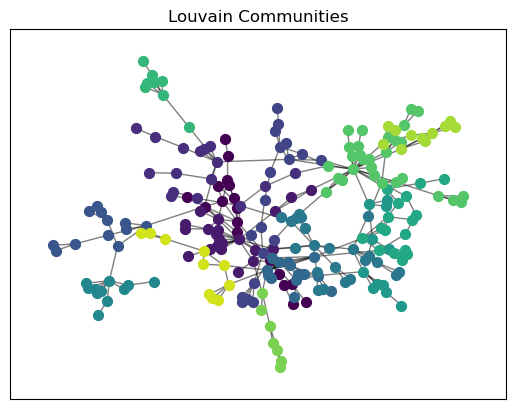

In [26]:
import matplotlib.pyplot as plt
# Visualization of Communities
def plot_communities(G, communities, title):
    pos = nx.spring_layout(G)
    cmap = plt.get_cmap('viridis')
    colors = [cmap(i / len(communities)) for i in range(len(communities))]
    for i, community in enumerate(communities):
        nx.draw_networkx_nodes(G, pos, nodelist=community, node_color=[colors[i]], node_size=50)
    nx.draw_networkx_edges(G, pos, alpha=0.5)
    plt.title(title)
    plt.show()
plot_communities(G, louvain_communities, 'Louvain Communities')

In [30]:
# Update nodes DataFrame with community labels
# Algorithm 3 - Louvain Method
def louvain_communities(G):
    partition = community_louvain.best_partition(G, weight='weight', resolution=1, random_state=140)
    communities = {}
    for node, comm in partition.items():
        if comm not in communities:
            communities[comm] = []
        communities[comm].append(node)
    return list(communities.values()), partition

louvain_communities, louvain_partition = louvain_communities(G)
louvain_modularity = modularity(G, louvain_communities)
print(f"Louvain Modularity: {round(louvain_modularity, 2)}")
nodes['louvain_community'] = nodes['ID'].map(louvain_partition)

Louvain Modularity: 0.78


In [35]:
nodes.to_csv('Giant_nodes_with_communities.csv', index=False)